In [10]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import statistics


### Dataset

You will use a dataset collected in July 2019 with statistics from the traffic using a tool called
Tstat (http://tstat.polito.it/). Tstat is a passive traffic monitor that exports flow records, i.e., a
single entry for each TCP/UDP stream in the network. Each flow record is composed of a rich
set of statistics.
The basic objects that passive monitoring tools capture are the packets that are transmitted
on the monitored link. We can group packets in flows if they share key IP header
information. A common choice is to consider: \
**Flow = (Protocol, IP Source Address, Source Port, IP Destination Address, Destination Port)** \
Tstat automatically aggregates by flow the traffic (packets) captured.
Beside classical flow-level fields, such as IP addresses, port numbers, packet and byte-wise
counters, Tstat extracts the domain names, which we use to label the TCP flows. The final
dataset is composed of 125 features, 122 numerical described with an initial “_” in the
featurename, plus the client IP address, the time when this flow was generated and the
label. We removed the information about the server IP.
You can find more information regarding the features in the file readme.txt.
The data provided is already divided in 2 parts for training (https_training.csv) and test
(https_test.csv).

Start the dataset on python. Substitute to the appropriate path to the dataset in your system

In [11]:
df_test = pd.read_csv("C:\\Users\\loren\\OneDrive\\Desktop\\PoliTo\\machine Learning\\https_test.csv")
df_train = pd.read_csv("C:\\Users\\loren\\OneDrive\\Desktop\\PoliTo\\machine Learning\\https_training.csv")



### Objective

Explore the dataset and learn about feature behavior at different levels. Use various data \
visualization techniques and statistical analysis \
Produce different visualizations and statistical analysis grouping the data at the flow level \
(rows of the dataset), at the IP level (clients) and domain name level (labels).



### 1.1: Distributions of features (EPDF or ECDF) per flow, domain name or IP


First we analyse amount of different categories for each stratification: Different client IPs and different Domains 

In [12]:
#how many different IPs/domain name in the dataset
print(f"there are {len(df_train)} different flows")
print(f"there are {len(df_train.groupby('c_ip'))} different client IPs")
print(f"there are {len(df_train.groupby('label'))} different Domains")


there are 147863 different flows
there are 738 different client IPs
there are 26 different Domains


Concerning the meaning of each feature, it is possible to notice some that carry very interpretable information: <br>


#### the most relevant features to analyse on the client side  are:

<ul> 
<li>  throughput / data volume : 
_c_bytes_all, _c_bytes_uniq, _c_appdataB, _c_pkts_all, _c_pkts_data

<li>reliability : 
_c_pkts_retx, _c_bytes_retx, _c_pkts_dup, _c_pkts_unk, _c_pkts_fc

<li>congestion window : 
_c_cwin_ini, _c_cwin_min, _c_cwin_max

<li>RTT : 
_c_rtt_avg, _c_rtt_min, _c_rtt_max, _c_rtt_std

<li>timing : 
_c_first, _c_last, _c_first_ack, _c_last_handshakeT

<li>MSS : 
_c_mss, _c_mss_max, _c_mss_min 
<br>


##### Important Server-side features 

Use at domain level and flow level:

<li>traffic volume
_s_bytes_all, _s_appdataB, _s_pkts_all

<li>retransmissions
_s_pkts_retx, _s_bytes_retx

<li>reliability
_s_pkts_dup, _s_pkts_ooo, _s_pkts_reor

<li>RTT
_s_rtt_avg, _s_rtt_max, _s_rtt_min, _s_rtt_std

<li>congestion window
_s_cwin_ini, _s_cwin_min, _s_cwin_max

<li>MSS
_s_mss, _s_mss_min, _s_mss_max  
<br>

_durat (duration)



#### Plotting the EPDF without grouping

In this way, it is possible to analyse the general behaviour of the features. Groupping wouldn't be reasonable since, as seen before, there to many categories to group by for this visualisation type

_c_mss 90% of its data equal to each other
_c_pkts_dup 90% of its data equal to each other
_c_pkts_fc 90% of its data equal to each other
_c_pkts_ooo 90% of its data equal to each other
_c_pkts_reor 90% of its data equal to each other
_c_pkts_rto 90% of its data equal to each other
_c_pkts_unfs 90% of its data equal to each other
_c_pkts_unk 90% of its data equal to each other
_c_sack_opt 90% of its data equal to each other
_c_syn_cnt 90% of its data equal to each other
_c_syn_retx 90% of its data equal to each other
_c_win_0 90% of its data equal to each other
_s_f1323_opt 90% of its data equal to each other
_s_mss 90% of its data equal to each other
_s_pkts_dup 90% of its data equal to each other
_s_pkts_fc 90% of its data equal to each other
_s_pkts_fs 90% of its data equal to each other
_s_pkts_ooo 90% of its data equal to each other
_s_pkts_reor 90% of its data equal to each other
_s_pkts_unfs 90% of its data equal to each other
_s_pkts_unrto 90% of its data equal to each other
_s

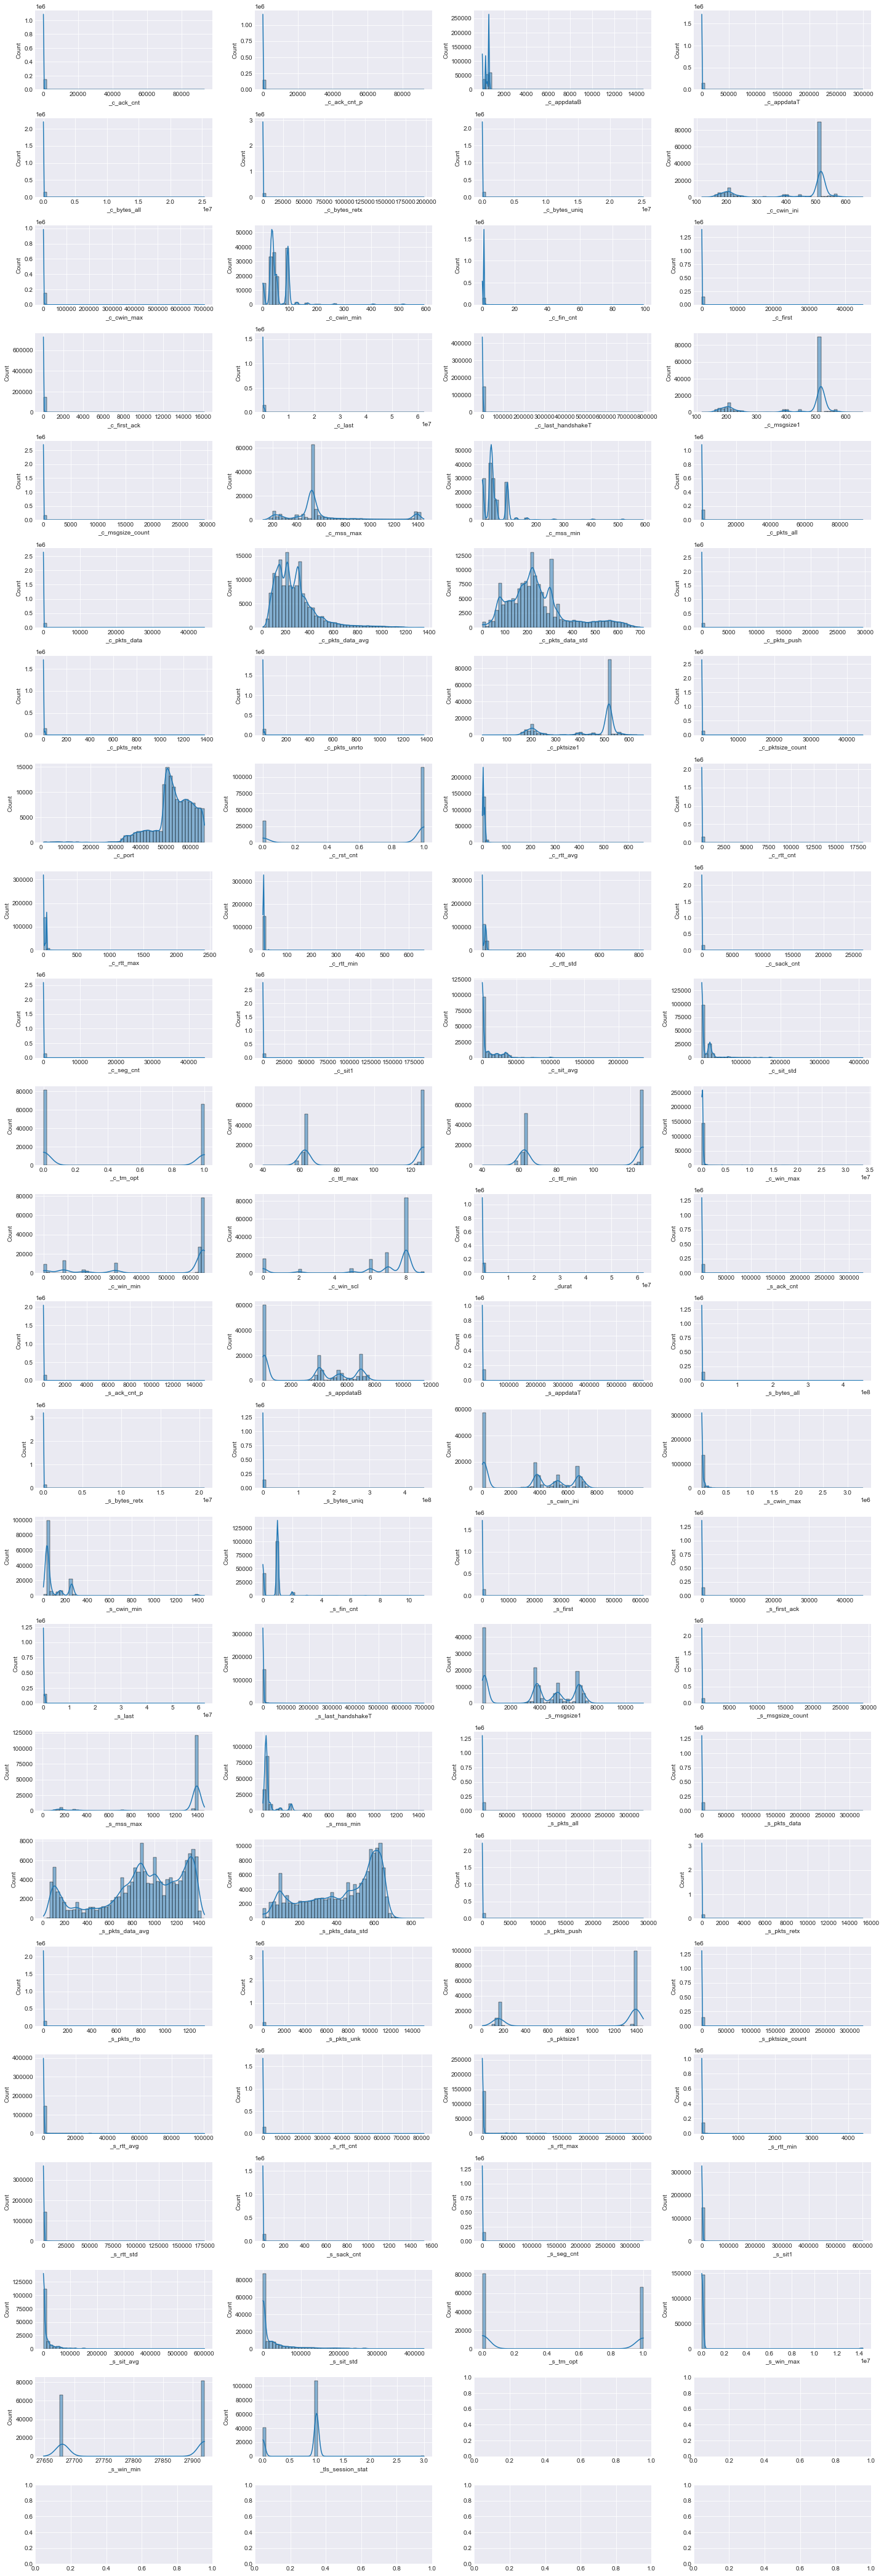

In [13]:

fig, ax = plt.subplots(24, 4, figsize=(20, 60))
ax = ax.flatten()  

j = 0

for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.05) == df_train[i].quantile(0.95):
            print(i, "90% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        sns.histplot(
            data = df_train, 
            x = i, 
            ax = ax[j],
            kde = True,
            bins = 50
            #hue = "label", # check the distribution of different flower types
        )
        j+=1
        


print(j, "plots")

# Global legend (instead of per-subplot)
#handles, labels = first_ax.get_legend_handles_labels()
#ig.legend(handles, labels, loc='upper center', ncol=len(labels)/3, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

When trying to group by domain, it takes forever!!!


In [14]:

#fig, ax = plt.subplots(24, 4, figsize=(20, 60))
#ax = ax.flatten()  
#
#j = 0
#
#for i in df_train.columns:
#    if i.startswith("_"):
#        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
#            print(i, "95% of its data equal to each other")
#            continue
#
#        # Plot ECDF for each class in "label"
#        sns.histplot(
#            data = df_train, 
#            x = i, 
#            ax = ax[j],
#            hue = "label", # check the distribution of different flower types
#        )
#
#        j+=1
#        
#
#
#print(j, "plots")
#
## Global legend (instead of per-subplot)
##handles, labels = first_ax.get_legend_handles_labels()
##ig.legend(handles, labels, loc='upper center', ncol=len(labels)/3, fontsize=14)
#
#plt.tight_layout(rect=[0, 0, 1, 0.97])
#plt.show()

### Comments

In [15]:
#plots that have very small bins have many unique values, in the case bellow, only a very faint line is visible at 0 (the mode)

print('_s_appdataT')
print('var: ', df_train['_s_appdataT'].var())
print('std: ', df_train['_s_appdataT'].mode())
print('unique values: ', len(df_train['_s_appdataT'].unique()))

#example of a plot that has few bins
print('unique values: ', len(df_train['_s_tm_opt'].unique()))

print('_s_rtt_avg')
print("var: ",df_train['_s_rtt_avg'].var())
print('mode: ',df_train['_s_rtt_avg'].mode())
print('unique values: ', len(df_train['_s_rtt_avg'].unique()))

#These graphs could be enhanced by beter automatic bin amount selection. but for now it is reasonable, since the plots bellow offer reasonable analysis 

_s_appdataT
var:  50893603.89748472
std:  0    0.0
dtype: float64
unique values:  52961
unique values:  2
_s_rtt_avg
var:  9321737.245248979
mode:  0    0.0
dtype: float64
unique values:  138011


### Plotting the ECDF for each domain

##### Custom ECDF plot function to avoid SNS limitations 

In [16]:

def ecdf(ax, x, label=None, color=None):
    """Plot an ECDF on the given matplotlib axis."""
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where='post', label=label, color=color)



_c_pkts_fc 95% of its data equal to each other
_c_pkts_ooo 95% of its data equal to each other
_c_pkts_reor 95% of its data equal to each other
_c_pkts_rto 95% of its data equal to each other
_c_pkts_unfs 95% of its data equal to each other
_c_sack_opt 95% of its data equal to each other
_c_syn_cnt 95% of its data equal to each other
_c_syn_retx 95% of its data equal to each other
_c_win_0 95% of its data equal to each other
_s_mss 95% of its data equal to each other
_s_pkts_dup 95% of its data equal to each other
_s_pkts_fc 95% of its data equal to each other
_s_pkts_fs 95% of its data equal to each other
_s_pkts_ooo 95% of its data equal to each other
_s_pkts_reor 95% of its data equal to each other
_s_pkts_unfs 95% of its data equal to each other
_s_pkts_unrto 95% of its data equal to each other
_s_port 95% of its data equal to each other
_s_sack_opt 95% of its data equal to each other
_s_syn_cnt 95% of its data equal to each other
_s_syn_retx 95% of its data equal to each other
_s_

TypeError: can't multiply sequence by non-int of type 'float'

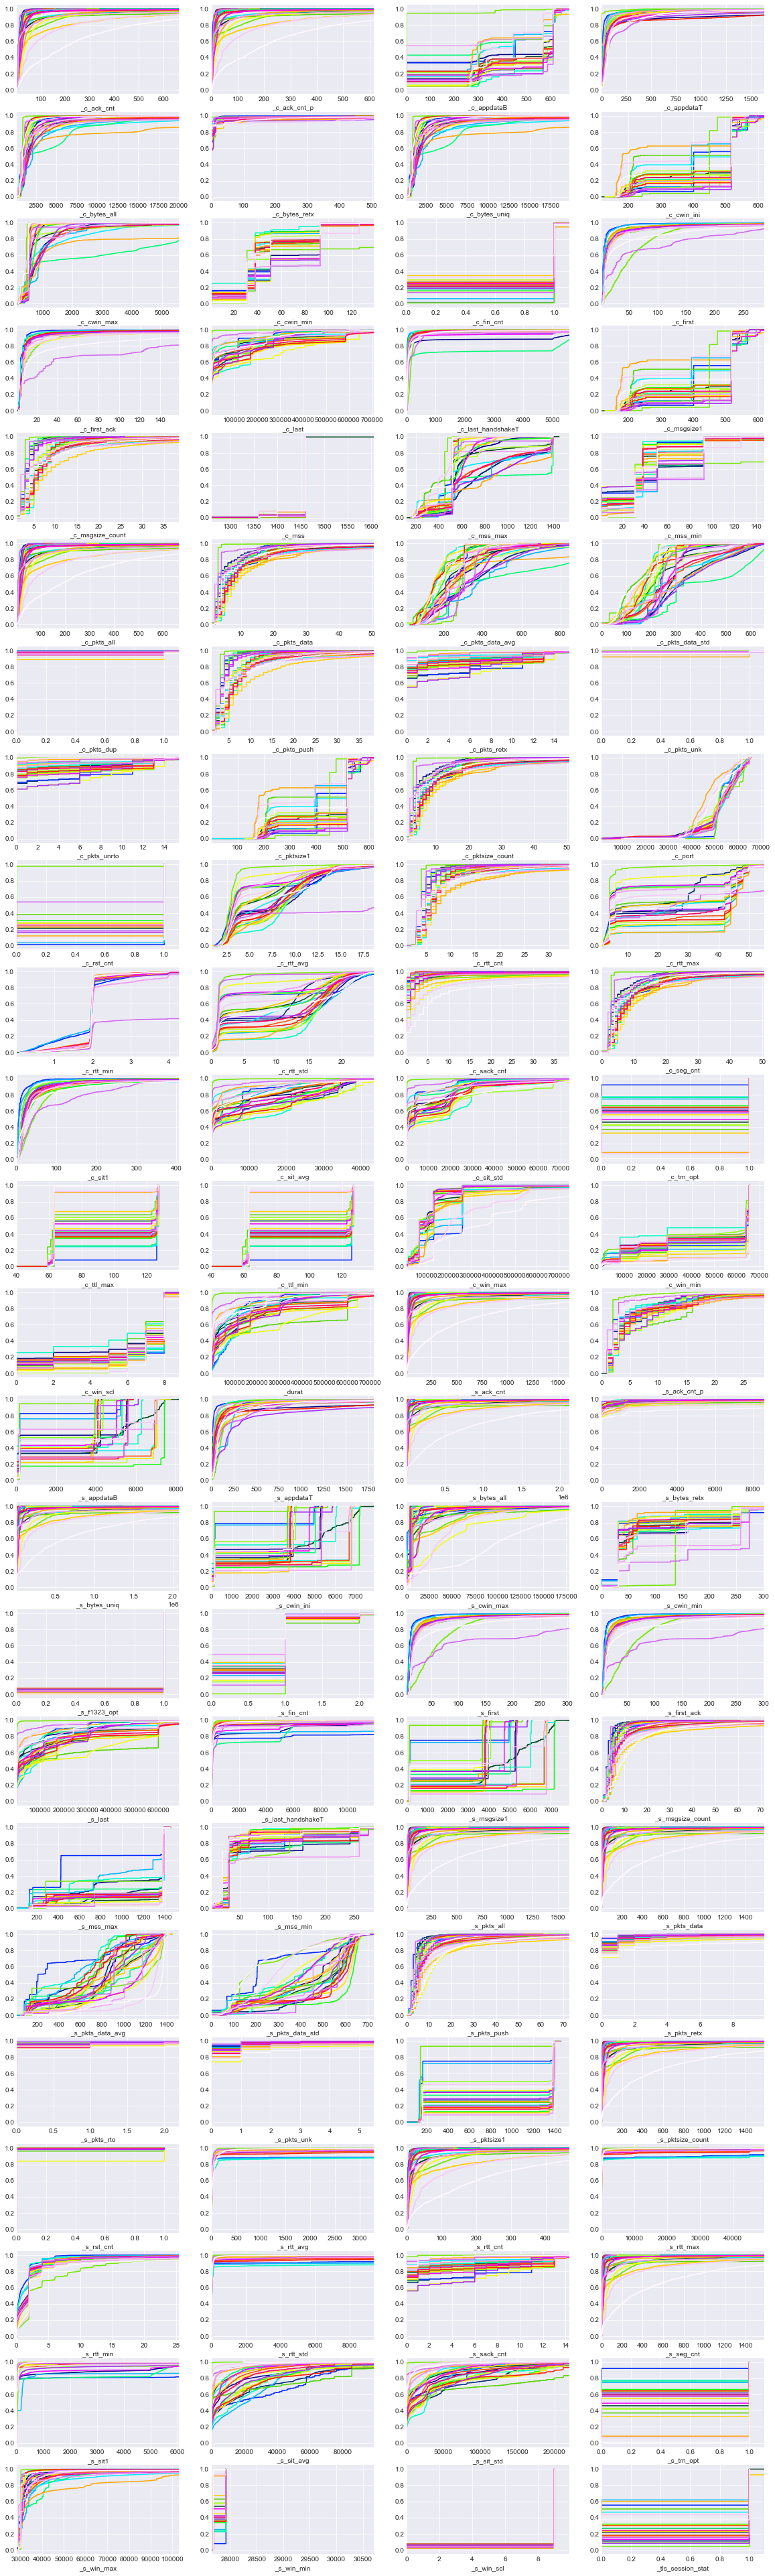

In [17]:
fig, ax = plt.subplots(24, 4, figsize=(20, 70))
ax = ax.flatten()  

j = 0
first_ax = None

labels = df_train['label'].unique()
n_labels = len(labels)

# 25+ distinguishable colors
palette = plt.cm.gist_ncar(np.linspace(0, 1, n_labels))

# Map label → color
label_to_color = {lab: palette[k] for k, lab in enumerate(labels)}


for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
            print(i, "95% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        labels = df_train['label'].unique()
        for lab in labels:
            ecdf(ax[j], 
                 df_train.loc[df_train['label'] == lab, i].dropna().values,
                 label=str(lab),
                 color=label_to_color[lab]
                 )
        ax[j].set_xlabel(i)
        # Store first axis for global legend
        if first_ax is None:
            first_ax = ax[j]

        # x-limits
        low = df_train[i].min()
        high = df_train[i].quantile(0.975)
        ax[j].set_xlim(low, high * 1.1)

        j += 1

print(j, "plots")

# Global legend (instead of per-subplot)
handles, labels = first_ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels)/3, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])



### Plotting the ECDF for  all the flows

_c_pkts_fc 95% of its data equal to each other
_c_pkts_ooo 95% of its data equal to each other
_c_pkts_reor 95% of its data equal to each other
_c_pkts_rto 95% of its data equal to each other
_c_pkts_unfs 95% of its data equal to each other
_c_sack_opt 95% of its data equal to each other
_c_syn_cnt 95% of its data equal to each other
_c_syn_retx 95% of its data equal to each other
_c_win_0 95% of its data equal to each other
_s_mss 95% of its data equal to each other
_s_pkts_dup 95% of its data equal to each other
_s_pkts_fc 95% of its data equal to each other
_s_pkts_fs 95% of its data equal to each other
_s_pkts_ooo 95% of its data equal to each other
_s_pkts_reor 95% of its data equal to each other
_s_pkts_unfs 95% of its data equal to each other
_s_pkts_unrto 95% of its data equal to each other
_s_port 95% of its data equal to each other
_s_sack_opt 95% of its data equal to each other
_s_syn_cnt 95% of its data equal to each other
_s_syn_retx 95% of its data equal to each other
_s_

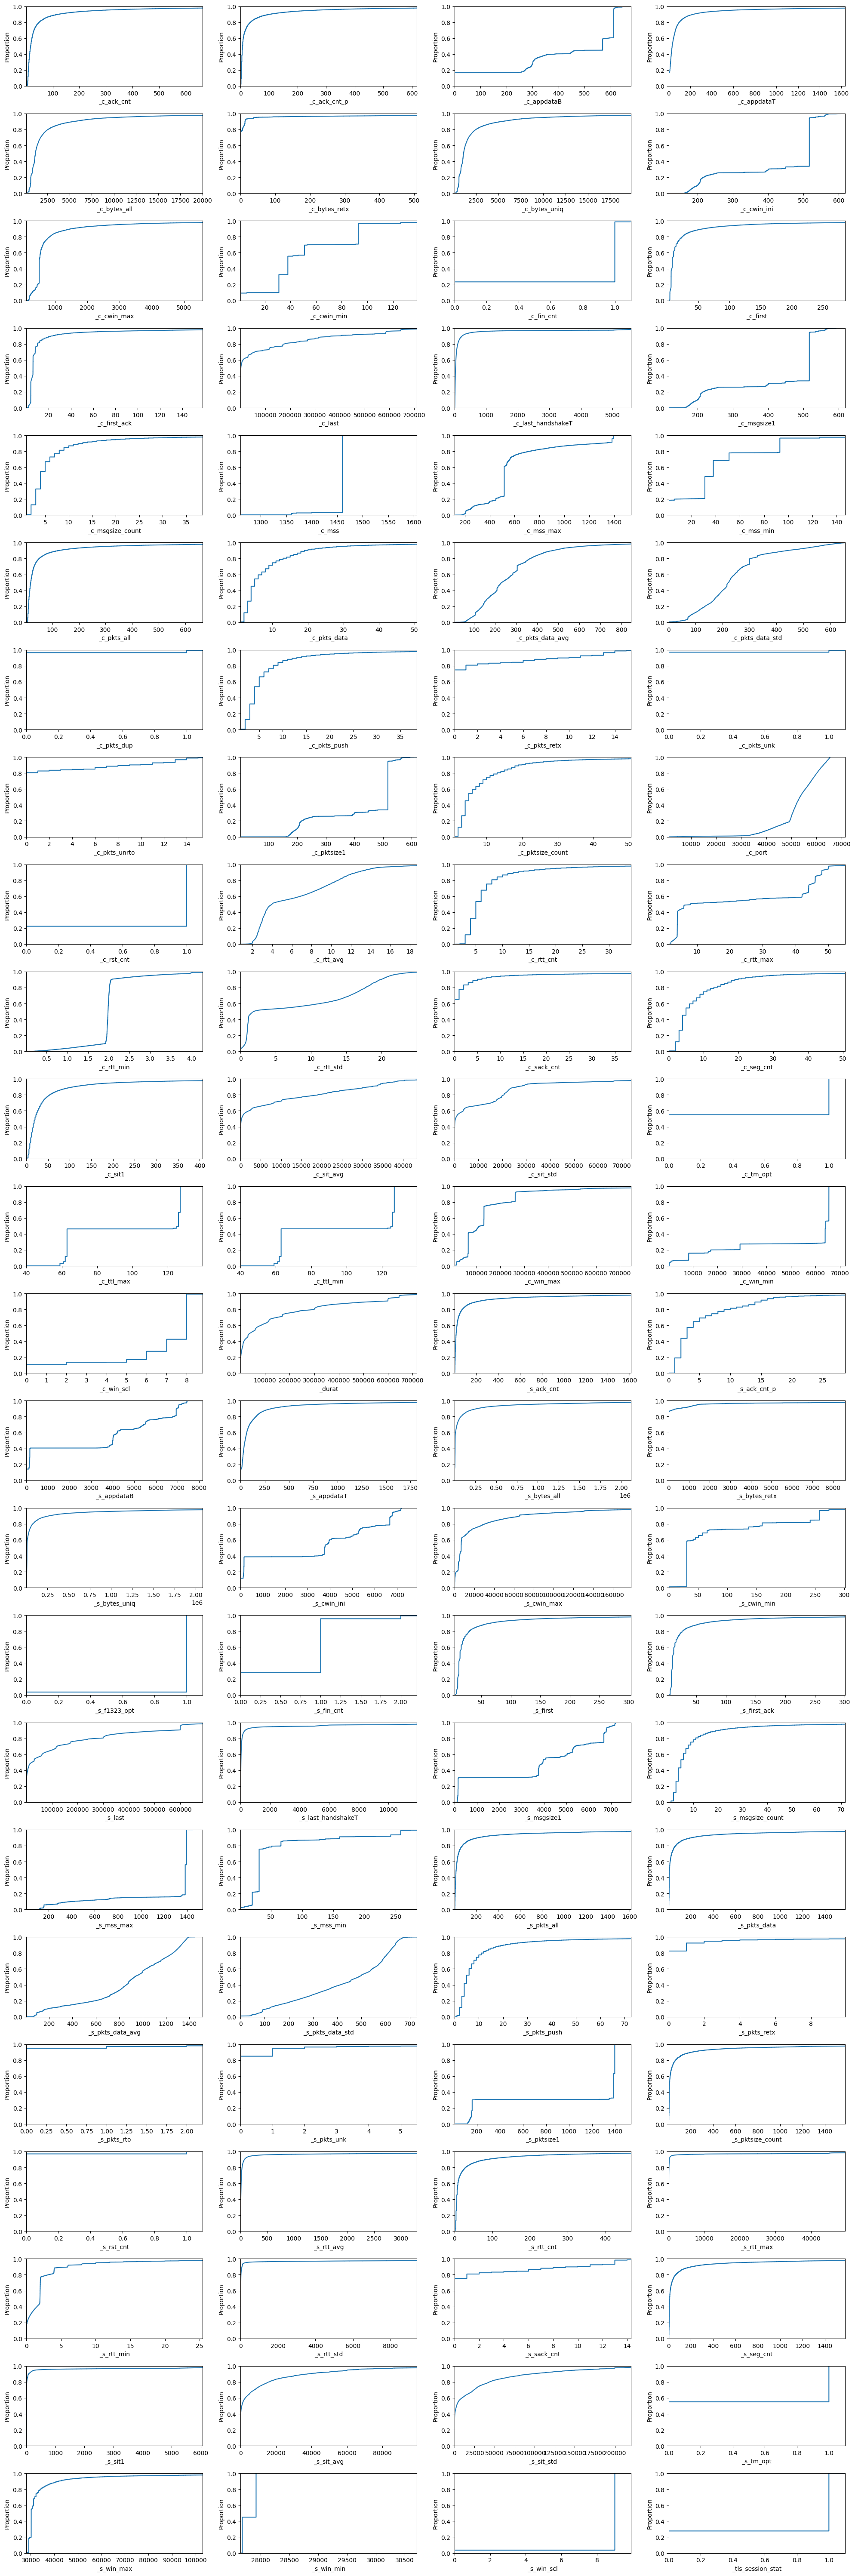

In [ ]:
fig, ax = plt.subplots(24, 4, figsize=(20, 60))
ax = ax.flatten()  

j = 0
first_ax = None

for i in df_train.columns:
    if i.startswith("_"):
        if df_train[i].quantile(0.025) == df_train[i].quantile(0.975):
            print(i, "95% of its data equal to each other")
            continue

        # Plot ECDF for each class in "label"
        sns.ecdfplot(data = df_train,
                     x = df_train[i],
                     ax = ax[j])


        # x-limits
        low = df_train[i].min()
        high = df_train[i].quantile(0.975)
        ax[j].set_xlim(low, high * 1.1)

        j += 1

print(j, "plots")


plt.tight_layout()
plt.show()

## 1.2 
### Statiscs for domain and IP groupped
 

I am merging the numerical features in :["mean", "median", "std", "min", "max"] \
since analysing feature per feature would be too much to handle <br>


#### the most relevant features to analyse on the client side  are:

<ul> 
<li>  throughput / data volume : 
_c_bytes_all, _c_bytes_uniq, _c_appdataB, _c_pkts_all, _c_pkts_data

<li>reliability : 
_c_pkts_retx, _c_bytes_retx, _c_pkts_dup, _c_pkts_unk, _c_pkts_fc

<li>congestion window : 
_c_cwin_ini, _c_cwin_min, _c_cwin_max

<li>RTT : 
_c_rtt_avg, _c_rtt_min, _c_rtt_max, _c_rtt_std

<li>timing : 
_c_first, _c_last, _c_first_ack, _c_last_handshakeT

<li>MSS : 
_c_mss, _c_mss_max, _c_mss_min 
<br>


##### Important Server-side features 

Use at domain level and flow level:

<li>traffic volume
_s_bytes_all, _s_appdataB, _s_pkts_all

<li>retransmissions
_s_pkts_retx, _s_bytes_retx

<li>reliability
_s_pkts_dup, _s_pkts_ooo, _s_pkts_reor

<li>RTT
_s_rtt_avg, _s_rtt_max, _s_rtt_min, _s_rtt_std

<li>congestion window
_s_cwin_ini, _s_cwin_min, _s_cwin_max

<li>MSS
_s_mss, _s_mss_min, _s_mss_max  
<br>

_durat (duration)




In [ ]:
def get_distinct(x):
    return(len(set(x)))

num_features = [col for col in df_train.columns if col.startswith("_")]

important_client_features = [
    # Traffic volume
    "_c_bytes_all",
    "_c_bytes_uniq",
    "_c_bytes_retx",
    "_c_appdataB",
    "_c_pkts_all",
    "_c_pkts_data",

    # Reliability / packet anomalies
    "_c_pkts_retx",
    "_c_pkts_dup",
    "_c_pkts_unk",
    "_c_pkts_fc",

    # Congestion window
    "_c_cwin_ini",
    "_c_cwin_min",
    "_c_cwin_max",

    # RTT statistics
    "_c_rtt_avg",
    "_c_rtt_min",
    "_c_rtt_max",
    "_c_rtt_std",

    # Timing
    "_c_first",
    "_c_last",
    "_c_first_ack",
    "_c_last_handshakeT",

    # MSS / segment size
    "_c_mss",
    "_c_mss_max",
    "_c_mss_min"
]

important_server_features = [
    # Traffic volume
    "_s_bytes_all",
    "_s_bytes_uniq",
    "_s_bytes_retx",
    "_s_appdataB",
    "_s_pkts_all",
    "_s_pkts_data",

    # Reliability / anomalies
    "_s_pkts_retx",
    "_s_pkts_dup",
    "_s_pkts_ooo",
    "_s_pkts_reor",
    "_s_pkts_unk",

    # Congestion window
    "_s_cwin_ini",
    "_s_cwin_min",
    "_s_cwin_max",

    # RTT statistics
    "_s_rtt_avg",
    "_s_rtt_min",
    "_s_rtt_max",
    "_s_rtt_std",

    # Timing
    "_s_first",
    "_s_last",
    "_s_first_ack",
    "_s_last_handshakeT",

    # MSS / segment size
    "_s_mss",
    "_s_mss_max",
    "_s_mss_min"
]



#Min, Max, Avg, Std
df_ip = df_train.groupby("c_ip")[num_features].agg(
    ["mean", "median", "std", "min", "max"]
)

#df_ip = df_train.groupby('c_ip').agg(
#    {'_c_pkts_all' : ['min', 'max', np.average, 'std'],
#     }
#)

print(df_ip)


                 _c_ack_cnt                                         \
                       mean   median         std      min      max   
c_ip                                                                 
67.32.100.15      26.606061     10.0   44.532249      5.0    219.0   
67.32.100.172     24.333333     25.0    2.081666     22.0     26.0   
67.32.100.217     16.052632      9.0   11.192625      6.0     37.0   
67.32.100.226     33.233333     21.0   51.893580      6.0    242.0   
67.32.100.228    182.722222     29.0  469.866415      7.0   1859.0   
...                     ...      ...         ...      ...      ...   
67.32.99.1        32.523810     28.0   23.049119      6.0     94.0   
67.32.99.11       12.750000      7.0   11.500000      7.0     30.0   
67.32.99.149      37.617978     22.0   94.647973      6.0    861.0   
67.32.99.33       67.724138     14.5  189.422279      6.0    959.0   
67.32.99.53    11030.000000  11030.0         NaN  11030.0  11030.0   

               _c_a

# 1.3

## Find most correlated features (at the 3 levels)

The idea is to follow as done in lab 5:

<ol>
    <li> Scale the data 
    <li> Draw the Corr matrix 
    <li> Explain that highly correlated feats can be suppressed from the analysis 
<ol>


We start by creating a copy with only the numerical values

In [ ]:
df_trainC = df_train.copy()
for i in df_trainC.columns:
    if not(i.startswith('_')):
        df_trainC = df_trainC.drop(i, axis=1) 


In [ ]:
# make a copy of the original dataset

# define the scaler
scaler = StandardScaler()

# for each column in the dataset, fit and transform the data
for col in df_trainC.columns:
    
    # fit the scaler on the data 
    scaler.fit(df_trainC[col].values.reshape(-1, 1))

    # transform the data
    df_trainC[col] = scaler.transform(df_trainC[col].values.reshape(-1, 1))

# OR you can do it in an easy way
# df_iris_copy[columns] = scaler.fit_transform(df_iris_copy[columns])



#### At flow level

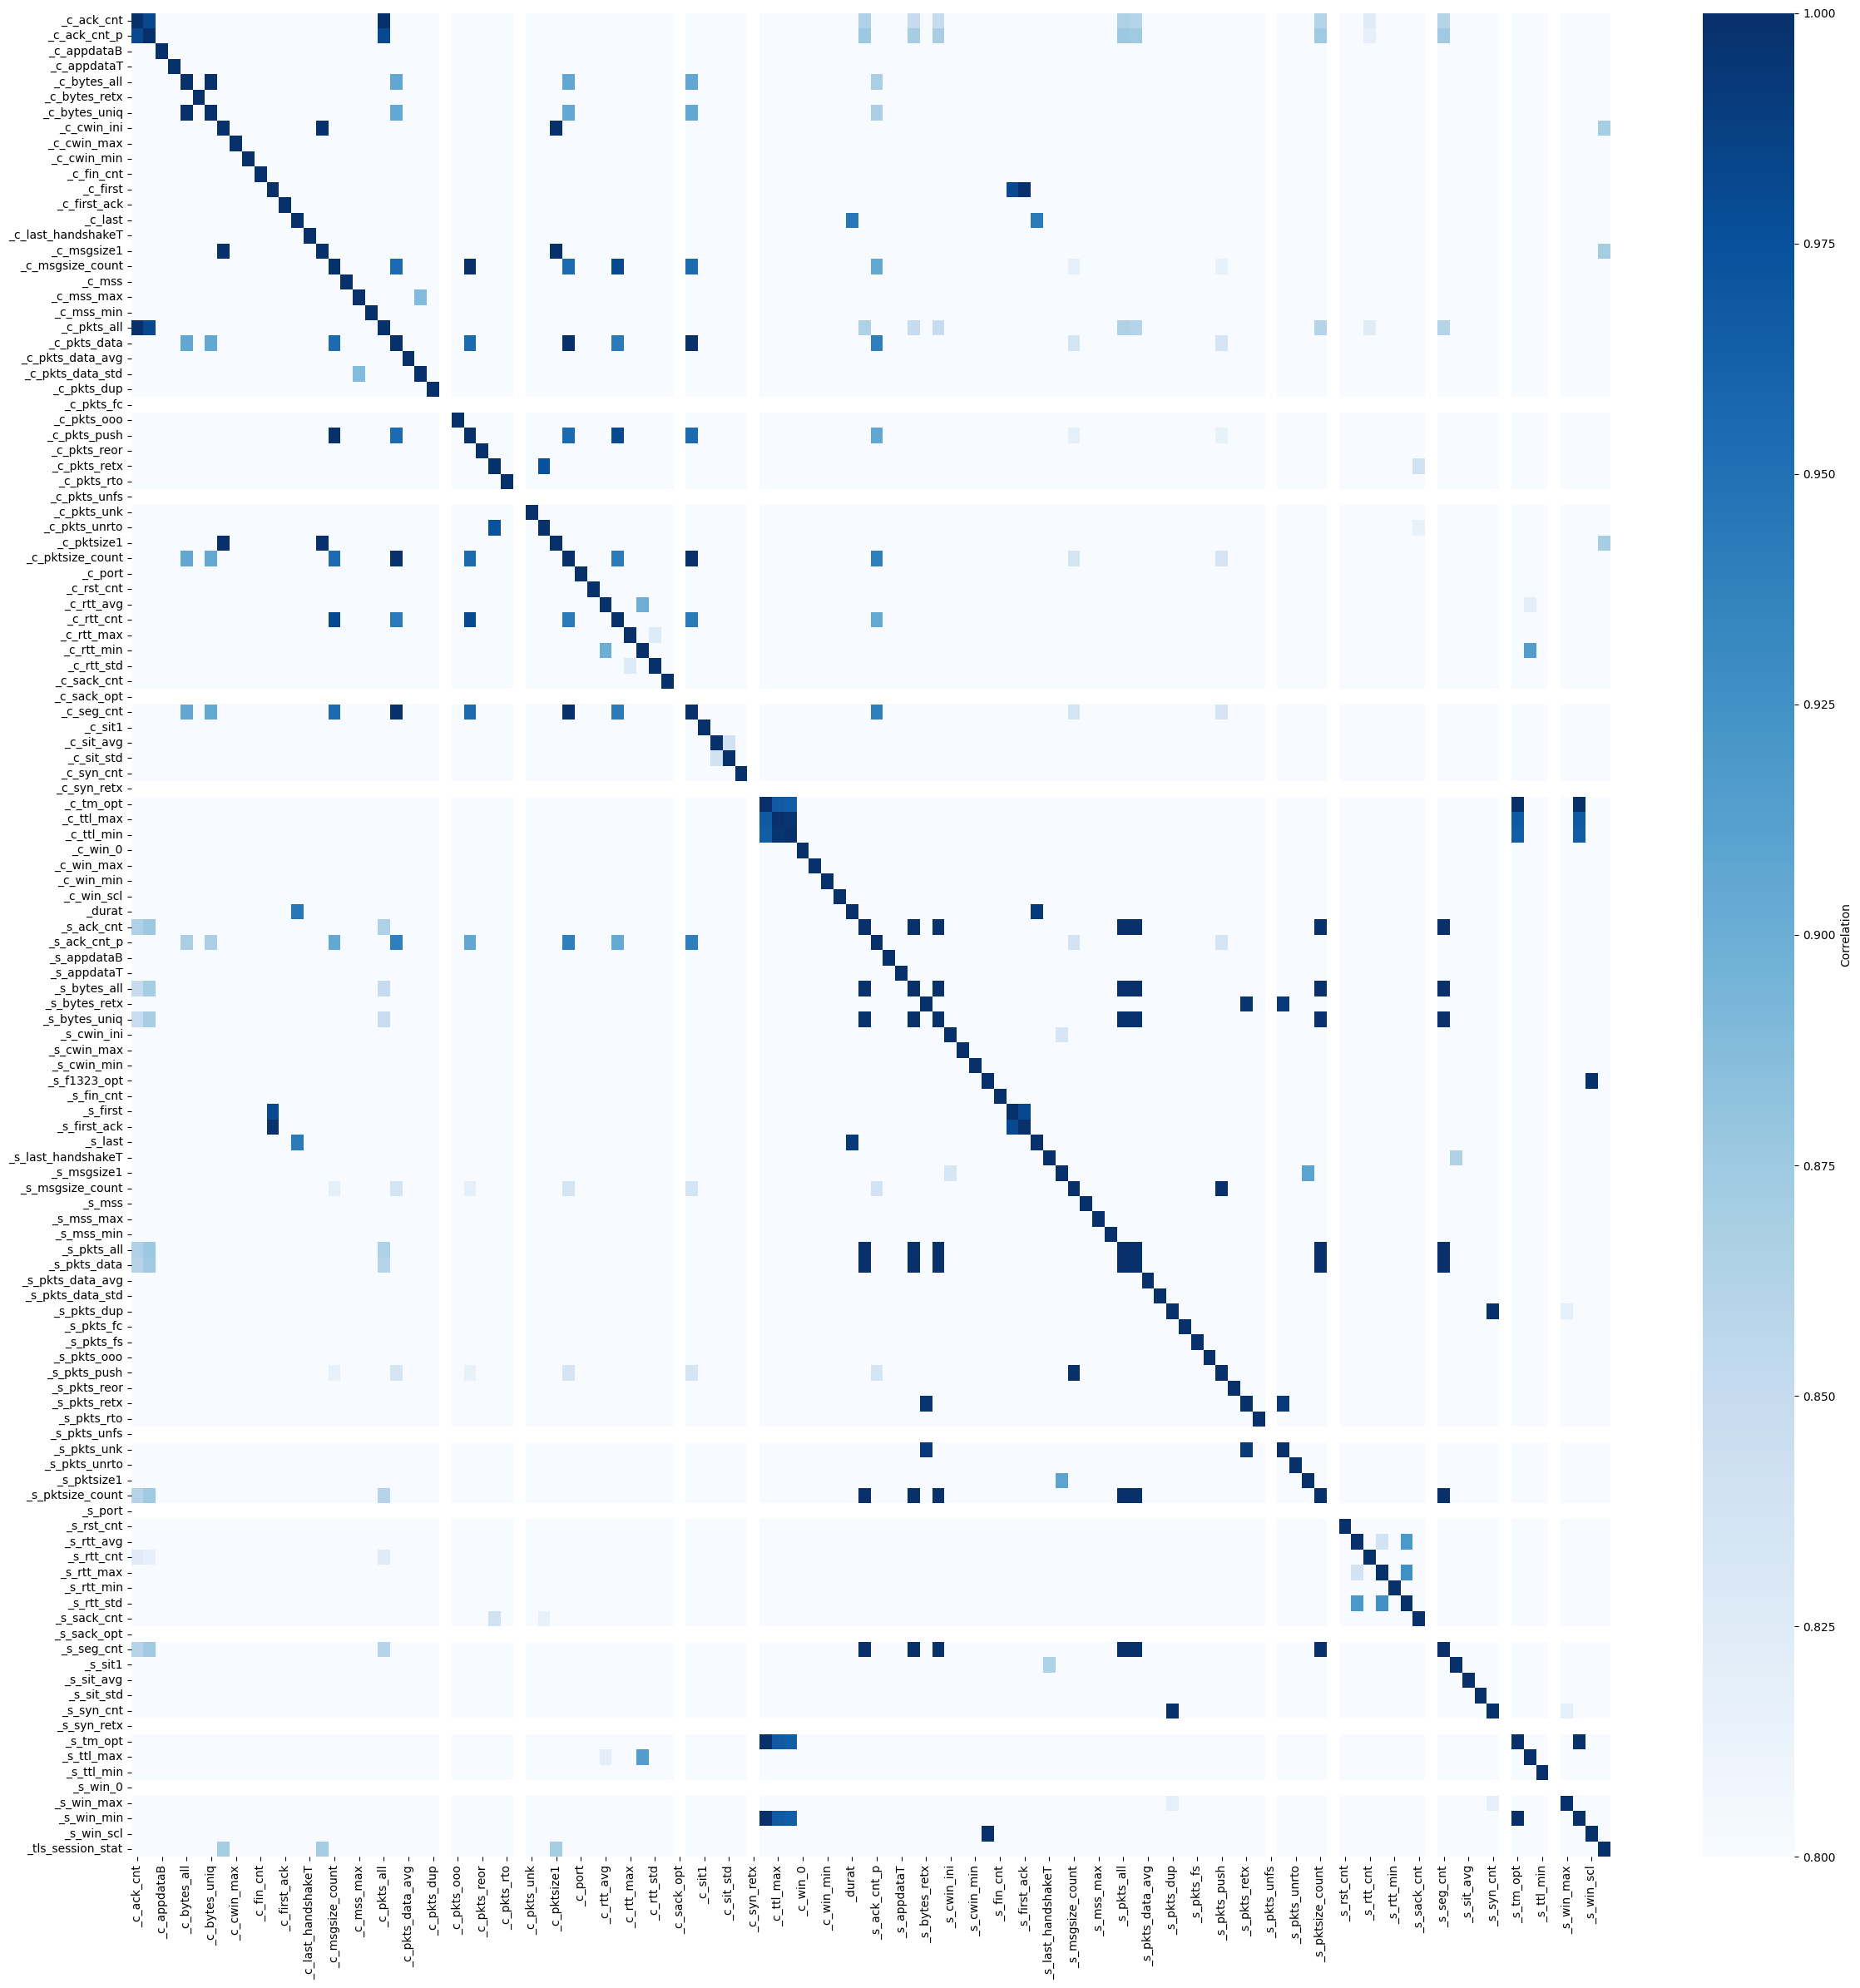

63


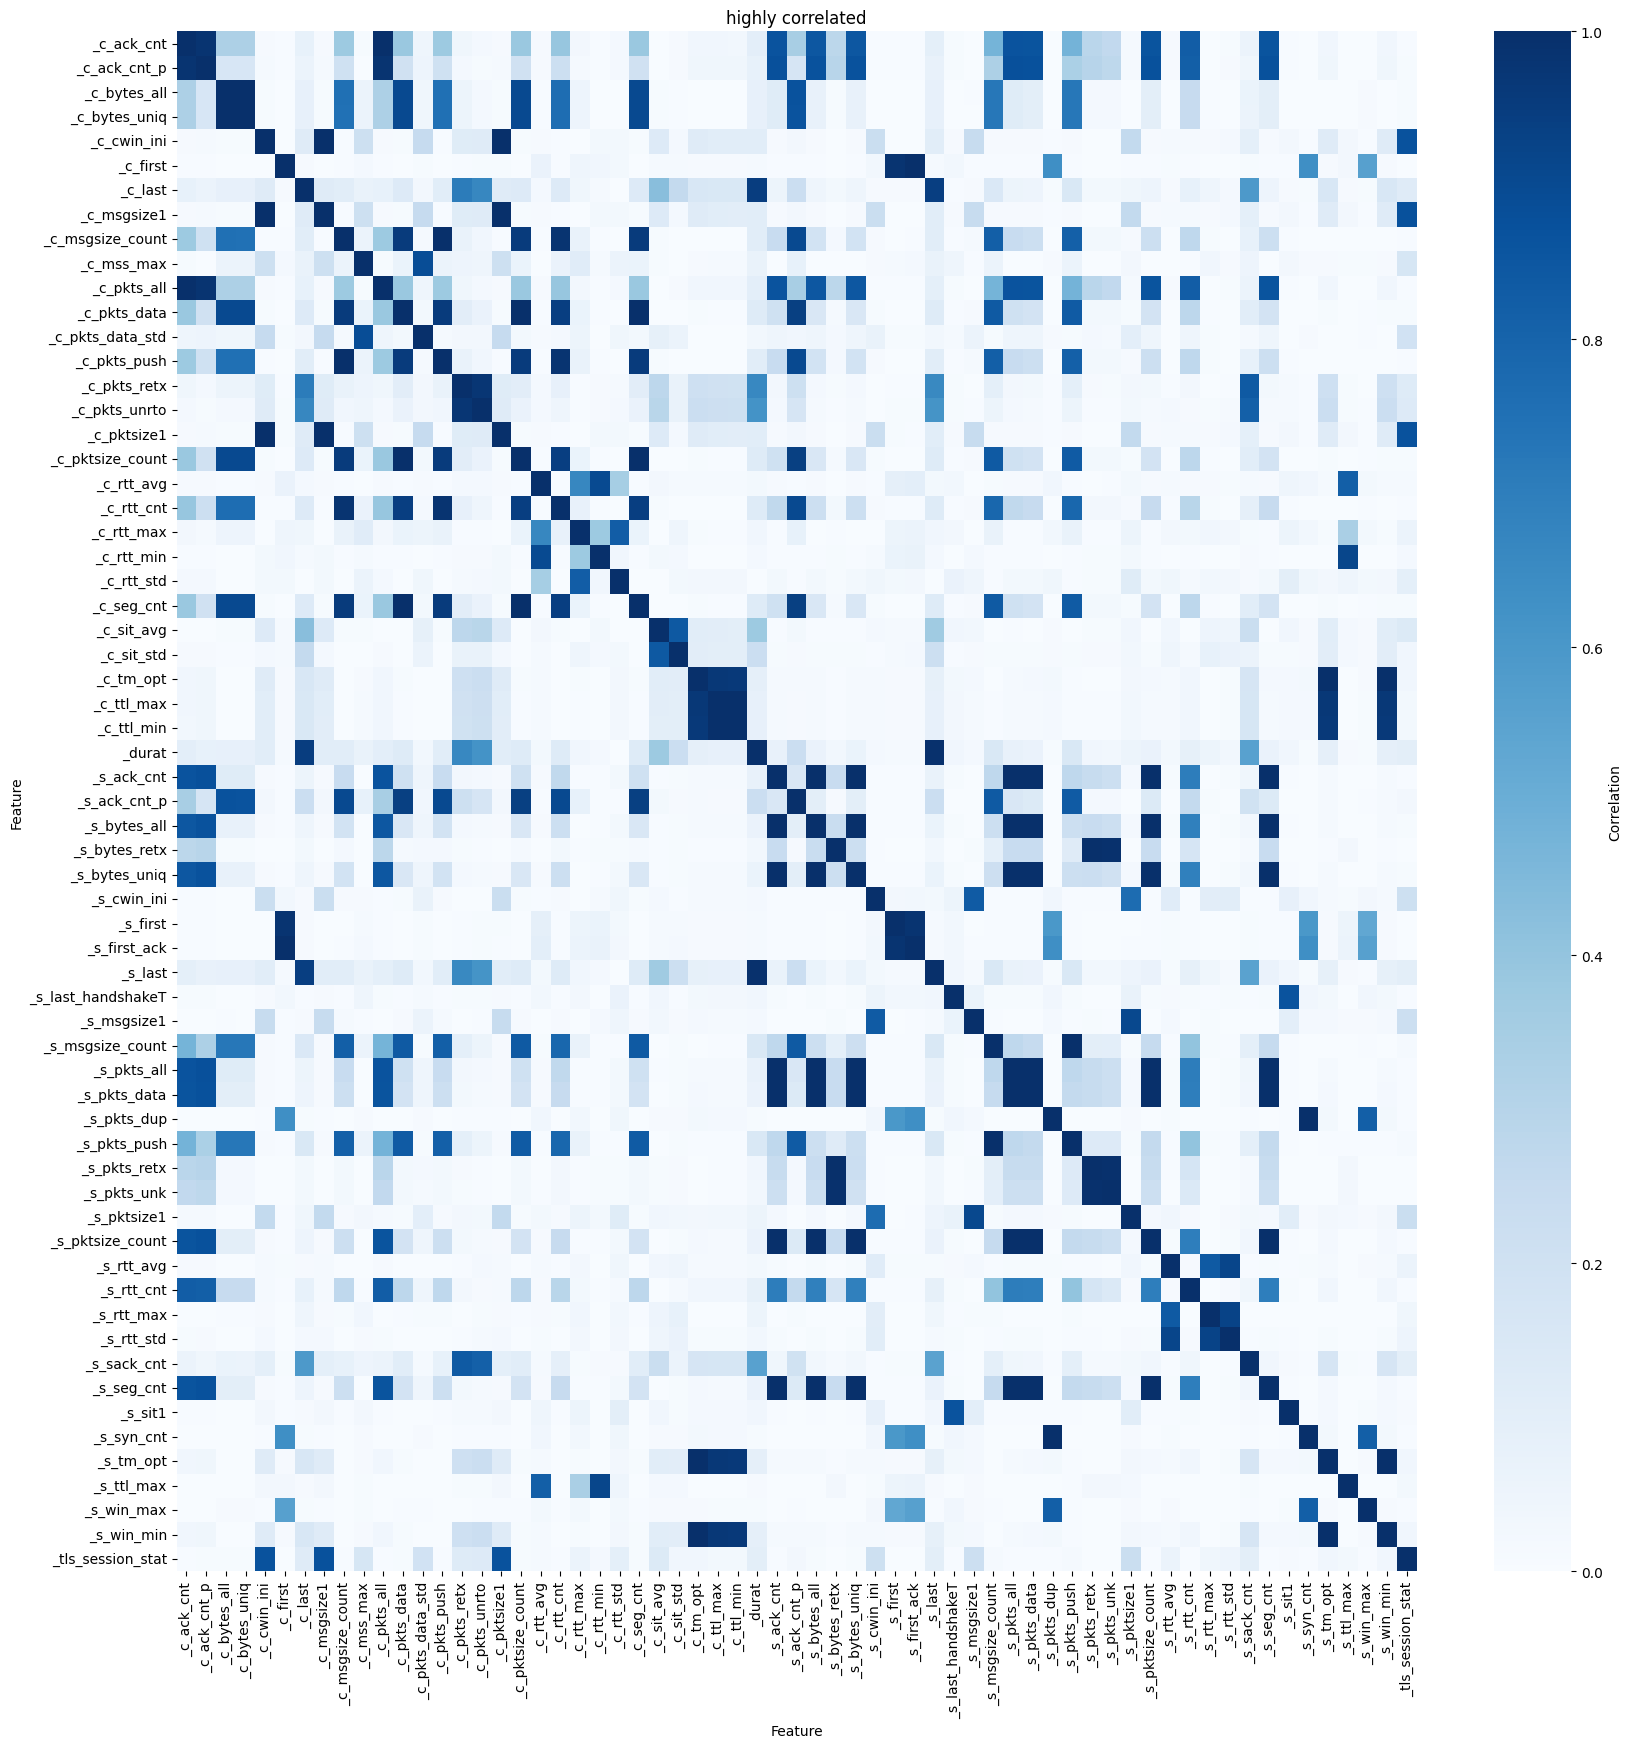

In [ ]:
columns= [i for i in range(df_trainC.shape[1])]
correlation_matrix = df_trainC.corr().abs()

# display the heatmap
plt.figure(figsize=(24,24))
sns.heatmap(correlation_matrix, cmap='Blues', vmin=0.8, vmax=1, cbar_kws={'label':'Correlation'})
plt.tight_layout()
plt.show()


#From the corr matrix, display only the ones that have correlation higher than 0.8
filtered = correlation_matrix[correlation_matrix>0.8]
columns_filtered = list(filtered.index)

for i in filtered:
    if (filtered[i].values[np.logical_not(np.isnan(filtered[i].values))] == [1]).all():
        columns_filtered.remove(i)

print(len(columns_filtered))

# Compute the heatmap
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix.loc[columns_filtered, columns_filtered], cmap='Blues', vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.title('highly correlated')
plt.show()




### At domain level


In [ ]:
print(df_train.groupby("label").size())

label
_other                   35083
adnxs.com                 3839
ads-twitter.com           1325
chartbeat.com             1413
contextweb.com            2824
disqus.com                3173
everesttech.net           3408
fastly-insights.com       1309
fastly.net                1869
ftcdn.net                 3455
giphy.com                 3886
githubusercontent.com     4271
krxd.net                 11144
newrelic.com              2182
outbrain.com              5637
pinterest.com             1967
polyfill.io               1270
redd.it                   3085
reddit.com                3457
scdn.co                  25322
slack-edge.com            1064
taboola.com              21018
twimg.com                 1024
twitch.tv                 2383
twitchcdn.net             1436
vimeocdn.com              1019
dtype: int64


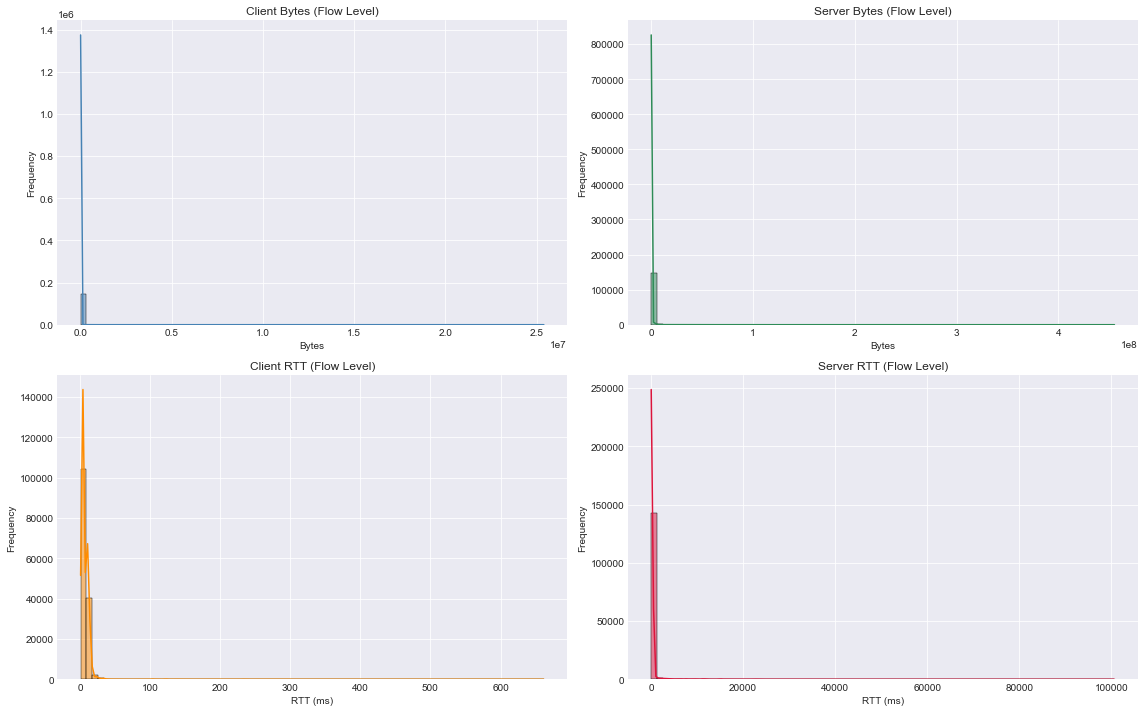

In [18]:
# --- PLOT STATISTICS: BYTES TRANSMITTED & RTT (FLOW LEVEL) ---

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-darkgrid")   # stile compatibile e sempre presente

# Features to plot
bytes_features = ["_c_bytes_all", "_s_bytes_all"]
rtt_features   = ["_c_rtt_avg", "_s_rtt_avg"]

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

# ----- BYTES DISTRIBUTION -----
sns.histplot(df_train["_c_bytes_all"], bins=80, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Client Bytes (Flow Level)")
ax[0].set_xlabel("Bytes"); ax[0].set_ylabel("Frequency")

sns.histplot(df_train["_s_bytes_all"], bins=80, kde=True, ax=ax[1], color="seagreen")
ax[1].set_title("Server Bytes (Flow Level)")
ax[1].set_xlabel("Bytes"); ax[1].set_ylabel("Frequency")

# ----- RTT DISTRIBUTION -----
sns.histplot(df_train["_c_rtt_avg"], bins=80, kde=True, ax=ax[2], color="darkorange")
ax[2].set_title("Client RTT (Flow Level)")
ax[2].set_xlabel("RTT (ms)"); ax[2].set_ylabel("Frequency")

sns.histplot(df_train["_s_rtt_avg"], bins=80, kde=True, ax=ax[3], color="crimson")
ax[3].set_title("Server RTT (Flow Level)")
ax[3].set_xlabel("RTT (ms)"); ax[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
